In [1]:
import torch
import numpy as np
import json
import os
from torch import nn
from collections import defaultdict

from utils import b2dVAE
from utils import b2dS2S

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae_path = "models/m-vae-b2d.pth"
s2s_path = "models/m-s2s-b2d.pth"

def load_b2dVAE(model_path, device):
    model = b2dVAE().to(device)
    checkpoint = torch.load(model_path, map_location=device)
    if "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
    else:
        model.load_state_dict(checkpoint)
    model.eval()
    return model

def load_s2s(model_path, device):
    model = b2dS2S().to(device)
    state = torch.load(model_path, map_location=device)
    if isinstance(state, dict) and "model_state_dict" in state:
        model.load_state_dict(state["model_state_dict"])
    else:
        model.load_state_dict(state)
    model.eval()
    return model
B2DVAE = load_b2dVAE(vae_path, device)
B2DS2S = load_s2s(s2s_path, device)

In [56]:
class DIRECTION_ENSEMBLES:
    DIRECTION_VECTORS_4 = [[1,0], [0, 1],[-1, 0], [0, -1]]
    DIRECTION_VECTORS_8 = [[1,0], [np.sqrt(2)/2, np.sqrt(2)/2], [0, 1], [-np.sqrt(2)/2, np.sqrt(2)/2],[-1, 0], [-np.sqrt(2)/2, -np.sqrt(2)/2], [0, -1], [np.sqrt(2)/2, -np.sqrt(2)/2]]
    DIRECTION_VECTORS_16 = [
        [1, 0],  # 0°
        [np.cos(np.pi/8), np.sin(np.pi/8)],  # 22.5°
        [np.sqrt(2)/2, np.sqrt(2)/2],  # 45°
        [np.sin(np.pi/8), np.cos(np.pi/8)],  # 67.5°
        [0, 1],  # 90°
        [-np.sin(np.pi/8), np.cos(np.pi/8)],  # 112.5°
        [-np.sqrt(2)/2, np.sqrt(2)/2],  # 135°
        [-np.cos(np.pi/8), np.sin(np.pi/8)],  # 157.5°
        [-1, 0],  # 180°
        [-np.cos(np.pi/8), -np.sin(np.pi/8)],  # 202.5°
        [-np.sqrt(2)/2, -np.sqrt(2)/2],  # 225°
        [-np.sin(np.pi/8), -np.cos(np.pi/8)],  # 247.5°
        [0, -1],  # 270°
        [np.sin(np.pi/8), -np.cos(np.pi/8)],  # 292.5°
        [np.sqrt(2)/2, -np.sqrt(2)/2],  # 315°
        [np.cos(np.pi/8), -np.sin(np.pi/8)]   # 337.5°
        ]
    DIRECTION_VECTORS_32 = [[np.cos(2*np.pi*i/32), np.sin(2*np.pi*i/32)] for i in range(32)]
 
   
direction_ensembles = DIRECTION_ENSEMBLES()

def gradient_select(target, cv_t, cv_t1_d, grad_t1_d, initial_relax=0.0, relax_step=0.02, max_relax=5.0):
    target = torch.as_tensor(target, dtype=torch.float32).to(device)
    cv_t = torch.as_tensor(cv_t, dtype=torch.float32).to(device)
    candidates = [torch.as_tensor(x, dtype=torch.float32).to(device) for x in cv_t1_d]
    grads = []
    for g in grad_t1_d:
        if isinstance(g, torch.Tensor):
            grads.append(g.detach().cpu().item())
        else:
            grads.append(float(g))

    current_dist = torch.norm(cv_t - target).item()
    relax_cof = float(initial_relax)

    chosen_idx = None

    while relax_cof <= max_relax:
        idxs = []
        for i, cand in enumerate(candidates):
            try:
                cand_dist = torch.norm(cand - target).item()
            except Exception:
                continue
            if cand_dist <= current_dist + relax_cof + 1e-9:
                idxs.append(i)
        if idxs:
            sub_grads = [grads[i] for i in idxs]
            min_sub_idx = int(np.argmin(sub_grads))
            chosen_idx = idxs[min_sub_idx]
            break
        relax_cof += relax_step

    if chosen_idx is None:
        chosen_idx = int(np.argmin(grads))

    sel_cv = candidates[chosen_idx]
    sel_grad = grads[chosen_idx]
    return chosen_idx, sel_cv, float(sel_grad)


def normalize_vector(v):
    v = np.array(v, dtype=float)
    norm = np.linalg.norm(v)
    return v / norm if norm > 0 else v

def tensor_to_serializable(data):
    if isinstance(data, torch.Tensor):
        return data.detach().cpu().numpy().tolist()
    elif isinstance(data, np.ndarray):
        return data.tolist()
    elif isinstance(data, (list, tuple)):
        return [tensor_to_serializable(x) for x in data]
    elif isinstance(data, dict):
        return {k: tensor_to_serializable(v) for k, v in data.items()}
    elif isinstance(data, (int, float, str, bool)) or data is None:
        return data
    else:
        return str(data)


def potential_energy(x, y):
    A1, A2, B = 5.0, 4.5, 3.0
    x1, y1, x2, y2 = 1.0, 2.0, 4.0, 3.5
    x0, y0 = 3.0, 3.0
    a1, b1, c1 = 0.3, 0.5, 0.2
    a2, b2, c2 = 0.4, 0.3, -0.3
    sigma_x, sigma_y = 2.0, 1.5
    x_t = torch.as_tensor(x, dtype=torch.float32).to(device)
    y_t = torch.as_tensor(y, dtype=torch.float32).to(device)

    well1 = -A1 * torch.exp(-a1*(x_t-x1)**2 - b1*(y_t-y1)**2 - c1*(x_t-x1)*(y_t-y1))
    well2 = -A2 * torch.exp(-a2*(x_t-x2)**2 - b2*(y_t-y2)**2 - c2*(x_t-x2)*(y_t-y2))
    barrier = B * torch.exp(-(x_t-x0)**4/sigma_x**4 - (y_t-y0)**4/sigma_y**4)

    return well1 + well2 + barrier

def GenLS2S(delta_cvs, sfmt, zt, P, step):
    delta_cvs = torch.as_tensor(delta_cvs, dtype=torch.float32).to(device)
    sfmt = torch.as_tensor(sfmt, dtype=torch.float32).to(device)
    P = torch.as_tensor(P, dtype=torch.float32).to(device)

    VAE_IN = sfmt.unsqueeze(0)  # [1, 2]
    e_t = potential_energy(VAE_IN[:, 0], VAE_IN[:, 1]).squeeze()  # scalar tensor

    with torch.no_grad():
        mu, logvar = B2DVAE.encode(VAE_IN)
        mu = mu.flatten()  # [dim]
        logvar = logvar.flatten()  # [dim]
    features = torch.cat([
        delta_cvs,      # (2,)
        e_t.reshape(1), # (1,)
        mu,             # (D,)
        logvar          # (D,)
    ])
    features = features.unsqueeze(0)  # [1, feature_dim]

    with torch.no_grad():
        S2S_Out = B2DS2S(features)  # [1, out_dim]

    e_pred = S2S_Out[:, 0].squeeze()              # scalar tensor
    mu_pred = S2S_Out[:, 1:9].reshape(1, -1)      # [1,8]
    logvar_pred = S2S_Out[:, 9:17].reshape(1, -1) # [1,8]

    delta_cvs_norm = torch.norm(delta_cvs)
    if delta_cvs_norm.item() > 1e-6:
        energy_diff = e_pred - e_t
        grad_pred = (energy_diff / delta_cvs_norm).item()
    else:
        grad_pred = 0.0

    try:
        zt_1 = int(zt)
    except Exception:
        zt_1 = 1

    n_recon = []
    n_e = []
    with torch.no_grad():
        n_samples = max(1, min(zt_1, 200))
        for _ in range(n_samples):
            z = B2DVAE.reparameterize(mu_pred, logvar_pred)   # shape [1, latent_dim]
            recon = B2DVAE.decode(z)                      
            recon = recon.view(1, -1)                         # [1, 2]
            recon_xy = recon.squeeze(0)                       # [2]
            recon_e = potential_energy(recon_xy[0], recon_xy[1]).squeeze()
            n_recon.append(recon_xy.cpu().numpy())
            try:
                n_e.append(float(recon_e.item()))
            except Exception:
                n_e.append(float(recon_e))

    if n_recon:
        mean_recon_pred_np = np.mean(n_recon, axis=0)
        mean_recon_pred = torch.from_numpy(mean_recon_pred_np).float().to(device)
    else:
        mean_recon_pred = torch.zeros(2, dtype=torch.float32).to(device)

    mean_recon_e = potential_energy(mean_recon_pred[0], mean_recon_pred[1]).squeeze()

    delta_cvs_real = mean_recon_pred - sfmt
    delta_cvs_real_norm = torch.norm(delta_cvs_real)
    target_direction = P - sfmt
    target_direction_norm = torch.norm(target_direction)
    if delta_cvs_real_norm.item() > 1e-6:
        grad_real = ((mean_recon_e - e_t) / delta_cvs_real_norm).item()
    else:
        grad_real = 0.0

    if delta_cvs_real_norm.item() > 1e-6 and target_direction_norm.item() > 1e-6:
        cos_sim = (torch.dot(delta_cvs_real, target_direction) / (delta_cvs_real_norm * target_direction_norm)).item()
    else:
        cos_sim = 0.0

    Latent = {
        'Input': {
            'delta_cv': delta_cvs.cpu().numpy().tolist(),
            'e': float(e_t.cpu().numpy().tolist()),
            'h_mu': mu.cpu().numpy().tolist(),
            'h_logvar': logvar.cpu().numpy().tolist()
        },
        'Output': {
            'e': float(e_pred.cpu().numpy().tolist()),
            'h_mu': mu_pred.squeeze(0).cpu().numpy().tolist(),
            'h_logvar': logvar_pred.squeeze(0).cpu().numpy().tolist(),
            'Grad_pred': float(grad_pred),
            'zt_1': int(zt_1)
        }
    }

    Real_space = {
        'Start_In': VAE_IN.squeeze(0).cpu().numpy().tolist(),
        'Recon_pred_Out': [x.tolist() for x in n_recon],
        'E_pred_Out': n_e,
        'mean_recon_pred': mean_recon_pred.cpu().numpy().tolist(),
        'mean_recon_e': float(mean_recon_e.cpu().numpy().tolist()),
        'Grad_real': float(grad_real),
        'Direction_similarity': float(cos_sim)
    }

    return Latent, Real_space, zt_1, float(grad_real), float(cos_sim), mean_recon_pred


def run_path_sampling(start, P, max_steps=10, d=0.2, Nd=4, workid = 1, initial_zt=100):
    if Nd == 4:
        DIRECTION_VECTORS = direction_ensembles.DIRECTION_VECTORS_4
    elif Nd == 8:
        DIRECTION_VECTORS = direction_ensembles.DIRECTION_VECTORS_8
    elif Nd == 16:
        DIRECTION_VECTORS = direction_ensembles.DIRECTION_VECTORS_16
    elif Nd == 32:
        DIRECTION_VECTORS = direction_ensembles.DIRECTION_VECTORS_32
    else:
        print("No such number of directions defined, using 4 directions")
        DIRECTION_VECTORS = direction_ensembles.IRECTION_VECTORS_4
    
    os.makedirs(f'results{workid}', exist_ok=True)
    with open(f'results{workid}/path_sampled_all_{int(d*10)}_{Nd}d.json', 'w') as f:
        json.dump({}, f)
    with open(f'results{workid}/grad_sample_{int(d*10)}_{Nd}d.txt', 'w') as f:
        f.write("step\tpred_grad\treal_grad\n") 
    with open(f'results{workid}/path_sampled_{int(d*10)}_{Nd}d.txt', 'w') as f:
        f.write("step\tx\ty\tenergy\n")

    current_pos = torch.tensor(start, dtype=torch.float32).to(device)
    zt = initial_zt
    path_data = []
    all_sampled_data = {}

    for step in range(max_steps):
        print(f"\n=== Step {step} ===")
        print(f"Current position: {current_pos.tolist()}")

        results = []
        delta_cvs_list = [np.array(v) * d for v in DIRECTION_VECTORS]

        for i, delta_cvs in enumerate(delta_cvs_list):
            print(f"Processing direction {i+1}: {delta_cvs}")
            Latent, Real_space, zt_out, grad_real, cos_sim, mean_recon_pred = GenLS2S(
                delta_cvs, current_pos.tolist(), zt, P, step)
            results.append({
                'direction': delta_cvs.tolist(),
                'grad_real': float(grad_real),
                'cos_sim': float(cos_sim),
                'zt_1': int(zt_out),
                'mean_recon_pred': mean_recon_pred.detach().cpu().numpy().tolist(),
                'data': {
                    'information': {
                        'Latent': Latent,
                        'Real_space': Real_space
                    }
                }
            })

        all_grads = [r['grad_real'] for r in results]
        all_cvt = [r['mean_recon_pred'] for r in results]

        d_sel, new_pos, grad_new = gradient_select(P, current_pos, all_cvt, all_grads)
        new_energy = float(potential_energy(new_pos[0], new_pos[1]).item())

        all_sampled_data[f"step_{step}"] = {
            'selected_direction': int(d_sel + 1),
            'grad_real': float(grad_new),
            'cos_sim': results[d_sel]['cos_sim'],
            'data': results[d_sel]['data']
        }

        with open(f'results{workid}/path_sampled_{int(d*10)}_{Nd}d.txt', 'a') as f:
            f.write(f"{step}\t{new_pos[0].item():.6f}\t{new_pos[1].item():.6f}\t{new_energy:.6f}\n")

        with open(f'results{workid}/grad_sample_{int(d*10)}_{Nd}d.txt', 'a') as f:
            try:
                pred_grad = results[d_sel]['data']['information']['Latent']['Output']['Grad_pred']
            except Exception:
                pred_grad = 0.0
            f.write(f"{step}\t{float(pred_grad):.6f}\t{float(results[d_sel]['grad_real']):.6f}\n")

        current_pos = new_pos.clone().to(device)
        path_data.append({
            'step': step,
            'position': current_pos.detach().cpu().numpy().tolist(),
            'energy': new_energy,
            'selected_direction': int(d_sel + 1),
            'zt': zt
        })

        if torch.norm(current_pos - torch.tensor(P, device=device)) < 0.01:
            print("Reached target position!")
            break

    with open(f'results{workid}/path_sampled_all_{int(d*10)}_{Nd}d.json', 'w') as f:
        json.dump(tensor_to_serializable(all_sampled_data), f, indent=2)

    return path_data


if __name__ == "__main__":

    start = [0.5, 2]
    P = [5, 5.5]  # target
    
    d_lis = [0.6]#[0.2, 0.4, 0.6]       # step size 
    Nd_lis = [8]#[4, 8, 16, 32]       # number of transition directions
    max_steps_lis = [[25]]#[[55, 70, 80, 110], [30,40,40,50], [20,35,40,45]] 
    work_id = 3   # replic
    for di in range(len(d_lis)):
        d = d_lis[di]
        for Ndi in range(len(Nd_lis)):
            Nd = Nd_lis[Ndi]
            max_steps = max_steps_lis[di][Ndi]
            path_data = run_path_sampling(start, P, max_steps, d, Nd, work_id)

    print("\nPath Sampling Completed!")
    print("Final path data:")
    for step in path_data:
        print(f"Step {step['step']}: Position {step['position']}, Energy {step['energy']:.4f}, zt={step['zt']}")


=== Step 0 ===
Current position: [0.5, 2.0]
Processing direction 1: [0.6 0. ]
Processing direction 2: [0.42426407 0.42426407]
Processing direction 3: [0.  0.6]
Processing direction 4: [-0.42426407  0.42426407]
Processing direction 5: [-0.6  0. ]
Processing direction 6: [-0.42426407 -0.42426407]
Processing direction 7: [ 0.  -0.6]
Processing direction 8: [ 0.42426407 -0.42426407]

=== Step 1 ===
Current position: [0.9401616454124451, 1.611261010169983]
Processing direction 1: [0.6 0. ]
Processing direction 2: [0.42426407 0.42426407]
Processing direction 3: [0.  0.6]
Processing direction 4: [-0.42426407  0.42426407]
Processing direction 5: [-0.6  0. ]
Processing direction 6: [-0.42426407 -0.42426407]
Processing direction 7: [ 0.  -0.6]
Processing direction 8: [ 0.42426407 -0.42426407]

=== Step 2 ===
Current position: [0.6304605007171631, 2.1366140842437744]
Processing direction 1: [0.6 0. ]
Processing direction 2: [0.42426407 0.42426407]
Processing direction 3: [0.  0.6]
Processing dir

# Plot pathways

RMSE between fitted sample path and original optimal points: 0.7283
RMSE between the two fitted curves: 0.0422


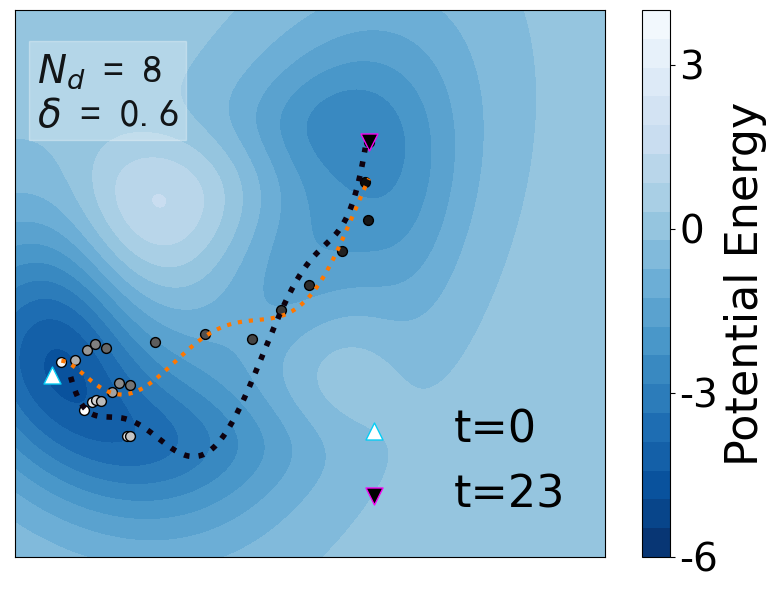

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import os
import pandas as pd
from scipy.interpolate import make_interp_spline

def potential_energy(x, y):
    A1 = 5.0
    a1, b1, c1 = 0.3, 0.5, 0.2
    x1, y1 = 1.0, 2.0

    A2 = 4.5
    a2, b2, c2 = 0.4, 0.3, -0.3
    x2, y2 = 4.0, 3.5

    B = 3.0
    x0, y0 = 3, 3.0
    sigma_x, sigma_y = 2.0, 1.5

    well1 = -A1 * np.exp(-a1*(x-x1)**2 - b1*(y-y1)**2 - c1*(x-x1)*(y-y1))
    well2 = -A2 * np.exp(-a2*(x-x2)**2 - b2*(y-y2)**2 - c2*(x-x2)*(y-y2))
    barrier = B * np.exp(-(x-x0)**4/sigma_x**4 - (y-y0)**4/sigma_y**4)

    return well1 + well2 + barrier

def plot_sampled_path(Nstep, d, N):
    x_grid = np.linspace(0, 8, 500)
    y_grid = np.linspace(0, 6, 500)
    X, Y = np.meshgrid(x_grid, y_grid)
    Z = potential_energy(X, Y)

    path_data = pd.read_csv(f'results3/path_sampled_{d}_{N}d.txt', sep='\t')
    x_coords = path_data['x'].values[:Nstep]
    y_coords = path_data['y'].values[:Nstep]

    optimal_path = pd.read_csv('optmal_path_ref.txt', sep=r'\s+')
    opt_x = optimal_path['X'].values
    opt_y = optimal_path['Y'].values

    fig, ax = plt.subplots(figsize=(8, 6))

    levels = np.linspace(-6, 4, 20)
    contour = ax.contourf(
        X, Y, Z,
        levels=levels,
        cmap="Blues_r",
        alpha=1,
        vmin=-6, vmax=4
    )
    
    cbar = fig.colorbar(contour, ax=ax, pad=0.05)
    cbar.set_label('Potential Energy', fontsize=32)
    cbar.ax.tick_params(labelsize=28)
    cbar.set_ticks([-6, -3, 0, 3])
    cbar.set_ticklabels(['-6','-3', '0', '3'])

    degree = 6
    p_sample = np.polyfit(x_coords, y_coords, deg=degree)
    p_optimal = np.polyfit(opt_x, opt_y, deg=degree)

    rmse_sample_vs_optimal = np.sqrt(np.mean((np.polyval(p_sample, opt_x) - opt_y) ** 2))
    print(f"RMSE between fitted sample path and original optimal points: {rmse_sample_vs_optimal:.4f}")

    t_smooth = np.linspace(0, 1, 500)
    x_fit = np.linspace(min(x_coords), max(x_coords), 500)
    y_fit_sample = np.polyval(p_sample, x_fit)
    ax.plot(x_fit, y_fit_sample, color="#FF7700", linestyle=':', linewidth=3)

    x_fit_optimal = np.linspace(min(opt_x), max(opt_x), 500)
    y_fit_optimal = np.polyval(p_optimal, x_fit_optimal)
    ax.plot(x_fit_optimal, y_fit_optimal, color="#0E020F", linestyle=':', linewidth=4)
    
    rmse_fitted_curves = np.sqrt(np.mean((y_fit_sample - np.polyval(p_sample, x_fit_optimal)) ** 2))
    print(f"RMSE between the two fitted curves: {rmse_fitted_curves:.4f}")

    cmap_bw = colors.LinearSegmentedColormap.from_list("white_to_black", ["white", "black"])
    norm = plt.Normalize(vmin=1, vmax=Nstep)
    for i in range(Nstep):
        ax.scatter(x_coords[i], y_coords[i],
                   color=cmap_bw(norm(i+1)), s=50, alpha=1, edgecolors="black")

    ax.scatter(0.5, 2, c="white", s=150, marker='^', label='t=0', edgecolors="#08CDF4")
    ax.scatter(x_coords[-1], y_coords[-1], c="black", s=150, marker='v', label=f't={Nstep}', edgecolors="#F408F0")
    
    ax.text(
        0.3, 5.1, f"$N_d$ = {N}\n$δ$ = {d/10}",
        fontsize=28,                   
        fontweight='bold',         
        fontfamily='SimHei',        
        color='black',                
        alpha=0.9,                
        ha='left',              
        va='center',              
        bbox=dict(                
            boxstyle='square',     
            facecolor='white',    
            edgecolor='white',  
            alpha=0.3,              
            pad=0.2               
        )
    )
    
    ax.set_xlabel('', fontsize=28)
    ax.set_xticks([])
    ax.set_ylabel('', fontsize=28)
    ax.set_yticks([])
    ax.legend(fontsize=32, loc='lower right', framealpha=0)

    plt.tight_layout()
    plt.savefig(f'figures3/2d_path_sampled_{d}_{N}d.tiff', format='tiff', dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    dstep = 6   
    dir_N = 8  
    Nstep = 23
    plot_sampled_path(Nstep, dstep, dir_N)